# Fase IV — Clustering Avanzado
## K-Means · GMM · Jerarquico · DEC (PyTorch)

**Input:** `latent_space_unified.csv` (6 factores AFE) + `vae_embeddings_50k.csv` (32 dims VAE)

> Xie, J., Girshick, R., & Farhadi, A. (2016). *Unsupervised Deep Embedding for Clustering Analysis*. ICML.

---

**Pipeline:**
```
X_cluster (5,267 x 38)
    │
    ├── ICA ──► X_ica (n componentes independientes)
    │               ├── K-Means     (obligatorio)
    │               ├── GMM         (obligatorio)
    │               └── Jerarquico  (recomendado)
    │
    └── DEC (PyTorch) ──► espacio latente z propio
                              └── Comparar los 4 metodos
═══════════════════════════════════════
PARTE I  — Clustering
PARTE II — Caracterizacion de Perfiles
═══════════════════════════════════════
```

---
# PARTE I — Clustering

## 0. Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA          # <-- nuevo: ICA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score
)
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 120

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.5.1+cu121


## 1. Carga y fusion de datos

In [25]:
afe = pd.read_csv('C:/Users/isape/OneDrive/Escritorio/ANALITICA/Proyecto1/punto3/data/afe-afc_latent_space_unified.csv')
vae = pd.read_csv('C:/Users/isape/OneDrive/Escritorio/ANALITICA/Proyecto1/punto3/data/vae_embeddings_50k_v3.csv')

print(f'AFE/AFC  (latent_space_unified) : {afe.shape}')
print(f'VAE embeddings  : {vae.shape}')

AFE/AFC  (latent_space_unified) : (5267, 9)
VAE embeddings  : (49735, 17)


In [26]:
# ── Features para clustering
AFE_FEATURES = [
    'orig_F_crediticia', 'orig_F_apalancamiento', 'orig_F_exposicion',
    'orig_F_contractual', 'comp_F_deterioro', 'macro_F_cohorte'
]
# state_ord y property_state → solo para caracterización post-clustering
CHAR_COLS    = ['state_ord', 'property_state']
VAE_FEATURES = [c for c in vae.columns if c.startswith('z')]

# JOIN por loan_id (inner → 5,267 loans)
df      = afe.merge(vae, on='loan_id', how='inner')
df_char = df[['loan_id'] + CHAR_COLS].copy()
X_raw   = df[AFE_FEATURES + VAE_FEATURES].copy()

print(f'Loans   : {len(df):,}')
print(f'Features: {X_raw.shape[1]}  ({len(AFE_FEATURES)} AFE + {len(VAE_FEATURES)} VAE)')
print(f'NaN     : {X_raw.isnull().sum().sum()}')
df.head(3)

Loans   : 5,267
Features: 22  (6 AFE + 16 VAE)
NaN     : 0


,loan_id,orig_F_crediticia,orig_F_apalancamiento,orig_F_exposicion,orig_F_contractual,comp_F_deterioro,macro_F_cohorte,state_ord,property_state,z0,...,z6,z7,z8,z9,z10,z11,z12,z13,z14,z15
0,105532112,-0.212073,0.088112,-1.650545,-0.297674,-0.397085,0.524983,3,AR,0.159917,...,-0.731969,0.748805,0.878726,-0.720811,-0.144432,0.168389,0.628254,0.944562,-0.820501,-0.927284
1,128332843,-0.049135,0.069399,-0.298420,0.014928,-0.370332,0.869782,5,CA,0.210913,...,-0.783852,1.221811,0.846853,-0.704994,-0.645973,0.220290,-0.771264,0.885081,-0.979163,0.715391
2,129090889,0.073291,0.059178,0.741486,0.260777,-0.397085,0.869782,11,GA,0.161798,...,0.116441,1.168110,0.979643,0.586194,0.003498,0.170896,-0.864879,0.937859,-0.988633,-1.366634


## 2. Preprocesamiento

In [27]:
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_raw)
X_tensor  = torch.tensor(X_scaled, dtype=torch.float32)
INPUT_DIM = X_scaled.shape[1]

print(f'Shape X_scaled : {X_scaled.shape}')
print(f'Mean ~ {X_scaled.mean():.4f}  |  Std ~ {X_scaled.std():.4f}')
print(f'Tensor PyTorch : {X_tensor.shape}')

Shape X_scaled : (5267, 22)
Mean ~ 0.0000  |  Std ~ 1.0000
Tensor PyTorch : torch.Size([5267, 22])


## 3. ICA — Transformacion a Componentes Independientes

Se aplica **FastICA** sobre `X_scaled` para obtener `X_ica`, la representacion que usaran K-Means, GMM y el clustering jerarquico.

**Por que ICA y no PCA:**
- PCA maximiza varianza → componentes no correlacionados
- ICA maximiza independencia estadistica → componentes no gaussianos
- Para datos financieros mixtos, los factores subyacentes tienden a ser no gaussianos (colas pesadas), lo que hace ICA mas adecuado

**Seleccion de n_components:** se escoge el valor que maximiza la kurtosis media absoluta de los componentes resultantes.

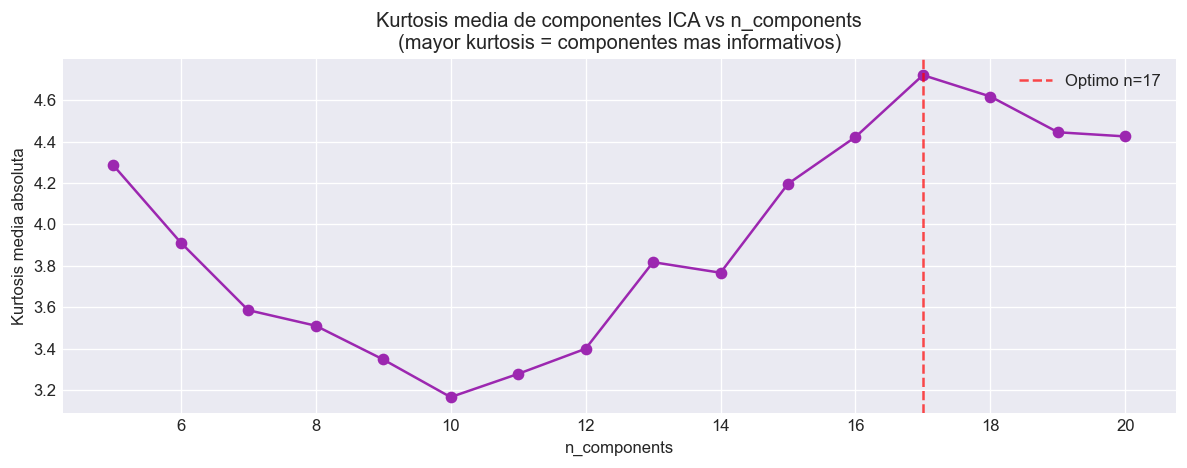

n_components optimo por kurtosis: 17


In [28]:
# ── Seleccion de n_components mediante kurtosis ──────────────────────────────
from scipy.stats import kurtosis

# Probamos ICA con n_components = 5..20 y medimos kurtosis media de los componentes
kurtosis_scores = {}
for n in range(5, min(21, INPUT_DIM + 1)):
    ica_test  = FastICA(n_components=n, random_state=RANDOM_STATE, max_iter=500)
    S_test    = ica_test.fit_transform(X_scaled)
    kurt_mean = np.abs(kurtosis(S_test, axis=0)).mean()
    kurtosis_scores[n] = kurt_mean

best_n = max(kurtosis_scores, key=kurtosis_scores.get)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(kurtosis_scores.keys()), list(kurtosis_scores.values()), 'o-', color='#9C27B0')
ax.axvline(best_n, ls='--', color='red', alpha=0.7, label=f'Optimo n={best_n}')
ax.set_title('Kurtosis media de componentes ICA vs n_components\n(mayor kurtosis = componentes mas informativos)')
ax.set_xlabel('n_components'); ax.set_ylabel('Kurtosis media absoluta')
ax.legend()
plt.tight_layout()
plt.show()

print(f'n_components optimo por kurtosis: {best_n}')

In [29]:
# ── Aplicar ICA final ────────────────────────────────────────────────────────
N_ICA = best_n   # o puedes fijar manualmente: N_ICA = 12

ica     = FastICA(n_components=N_ICA, random_state=RANDOM_STATE, max_iter=1000, tol=1e-4)
X_ica   = ica.fit_transform(X_scaled)   # (5267, N_ICA) — scores de componentes independientes

print(f'X_ica shape          : {X_ica.shape}')
print(f'Varianza explicada   : ICA no maximiza varianza — maximiza independencia estadistica')
print(f'Kurtosis por componente:')
for i, k in enumerate(np.abs(kurtosis(X_ica, axis=0))):
    print(f'  IC-{i+1:02d}: {k:.3f}')

X_ica shape          : (5267, 17)
Varianza explicada   : ICA no maximiza varianza — maximiza independencia estadistica
Kurtosis por componente:
  IC-01: 1.494
  IC-02: 1.452
  IC-03: 18.353
  IC-04: 1.592
  IC-05: 1.265
  IC-06: 0.836
  IC-07: 6.070
  IC-08: 19.078
  IC-09: 14.944
  IC-10: 0.796
  IC-11: 2.435
  IC-12: 1.001
  IC-13: 5.863
  IC-14: 2.436
  IC-15: 0.371
  IC-16: 1.547
  IC-17: 0.721


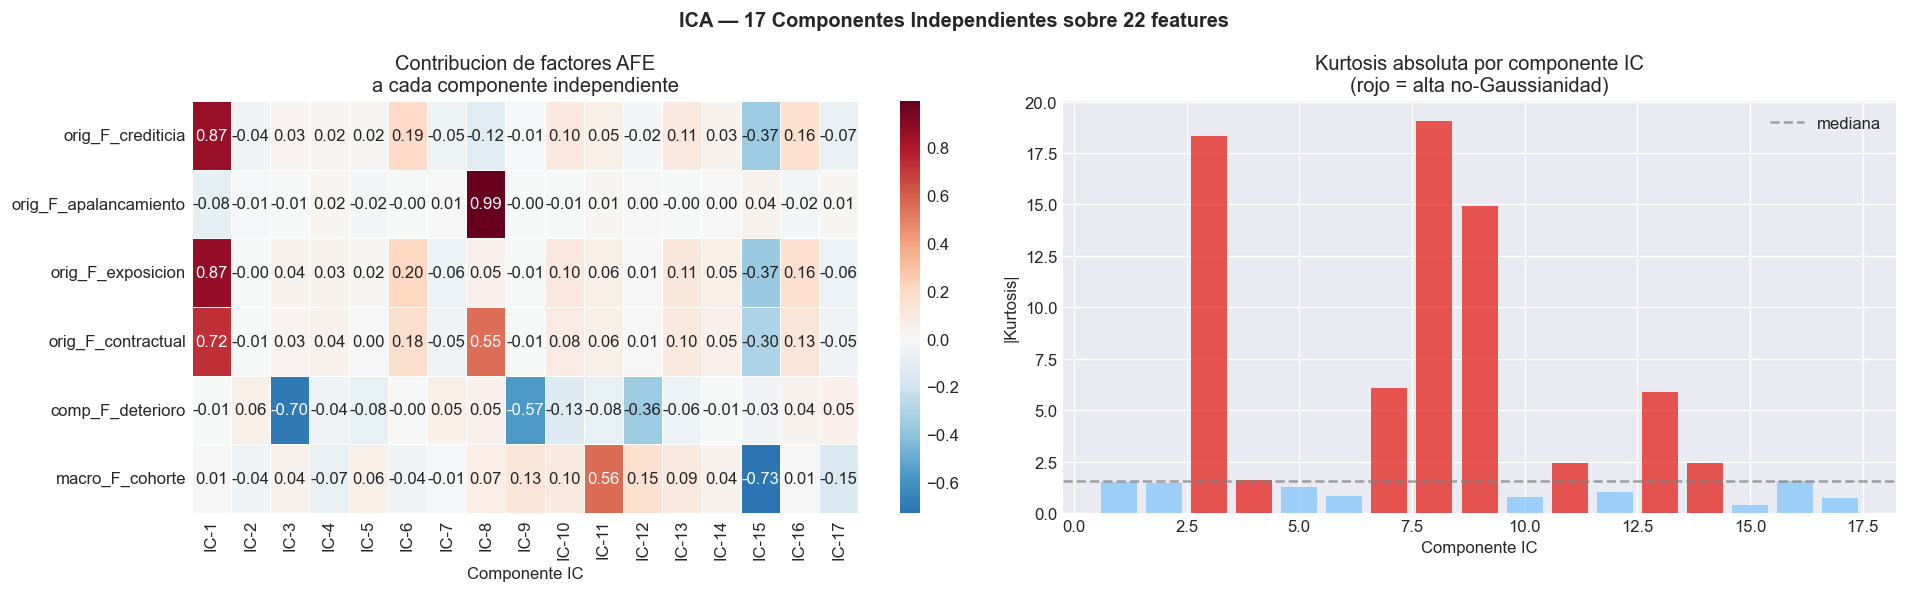

In [30]:
# ── Visualizar componentes ICA (heatmap de mixing matrix) ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'ICA — {N_ICA} Componentes Independientes sobre {INPUT_DIM} features',
             fontsize=12, fontweight='bold')

# Heatmap de la matriz de mezcla (cuanto contribuye cada feature a cada IC)
mixing = pd.DataFrame(
    ica.mixing_[:, :N_ICA],
    index=AFE_FEATURES + VAE_FEATURES,
    columns=[f'IC-{i+1}' for i in range(N_ICA)]
)
# Solo mostrar los factores AFE (interpretables) en la primera grafica
mixing_afe = mixing.loc[AFE_FEATURES]
sns.heatmap(mixing_afe, cmap='RdBu_r', center=0, ax=axes[0],
            annot=True, fmt='.2f', linewidths=0.3)
axes[0].set_title('Contribucion de factores AFE\na cada componente independiente')
axes[0].set_xlabel('Componente IC')

# Kurtosis de cada IC
kurt_vals = np.abs(kurtosis(X_ica, axis=0))
colors_k  = ['#E53935' if k > np.median(kurt_vals) else '#90CAF9' for k in kurt_vals]
axes[1].bar(range(1, N_ICA + 1), kurt_vals, color=colors_k, alpha=0.85)
axes[1].axhline(np.median(kurt_vals), ls='--', color='gray', alpha=0.7, label='mediana')
axes[1].set_title('Kurtosis absoluta por componente IC\n(rojo = alta no-Gaussianidad)')
axes[1].set_xlabel('Componente IC'); axes[1].set_ylabel('|Kurtosis|')
axes[1].legend()

OUT_DIR = Path('C:/Users/isape/OneDrive/Escritorio/ANALITICA/Proyecto1/punto3/4_CLUSTER')
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.tight_layout()
plt.savefig(OUT_DIR / '00_ica_components.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Seleccion de K (K = 3..8)

Metricas internas sobre `X_ica`:
- **Silhouette**, **Calinski-Harabasz**, **Davies-Bouldin** para K-Means
- **BIC** y **Generalizability G = L_train / L_val** para GMM

La Generalizability detecta cuando agregar mas clusters genera overfitting: una caida brusca en G indica el K optimo.

In [31]:
K_RANGE = range(3, 9)
records = []

X_tr_ica, X_val_ica = train_test_split(X_ica, test_size=0.2, random_state=RANDOM_STATE)

for k in K_RANGE:
    # ---- KMeans sobre X_ica ----
    km        = KMeans(n_clusters=k, init='k-means++', n_init=20,
                       random_state=RANDOM_STATE, max_iter=500)
    labels_km = km.fit_predict(X_ica)
    sil_km    = silhouette_score(X_ica, labels_km, random_state=RANDOM_STATE)
    ch_km     = calinski_harabasz_score(X_ica, labels_km)
    db_km     = davies_bouldin_score(X_ica, labels_km)

    # ---- GMM sobre X_ica ----
    gmm_k      = GaussianMixture(n_components=k, covariance_type='full',
                                 n_init=5, random_state=RANDOM_STATE)
    gmm_k.fit(X_tr_ica)
    labels_gmm = gmm_k.predict(X_ica)
    sil_gmm    = silhouette_score(X_ica, labels_gmm, random_state=RANDOM_STATE)
    bic_full   = gmm_k.bic(X_ica)
    G          = gmm_k.bic(X_tr_ica) / (gmm_k.bic(X_val_ica) + 1e-9)

    records += [
        {'K': k, 'method': 'KMeans', 'silhouette': round(sil_km, 4),
         'calinski_harabasz': round(ch_km, 2), 'davies_bouldin': round(db_km, 4),
         'bic': np.nan, 'generalizability': np.nan},
        {'K': k, 'method': 'GMM', 'silhouette': round(sil_gmm, 4),
         'calinski_harabasz': np.nan, 'davies_bouldin': np.nan,
         'bic': round(bic_full, 2), 'generalizability': round(G, 4)},
    ]
    print(f'K={k} | KMeans sil={sil_km:.3f} CH={ch_km:,.0f} DB={db_km:.3f} '
          f'| GMM sil={sil_gmm:.3f} BIC={bic_full:,.0f} G={G:.4f}')

metrics_df = pd.DataFrame(records)
print('Metricas calculadas sobre X_ica')

K=3 | KMeans sil=0.104 CH=321 DB=3.041 | GMM sil=0.033 BIC=185,433 G=3.6599
K=4 | KMeans sil=0.079 CH=313 DB=2.879 | GMM sil=0.059 BIC=169,925 G=3.5302
K=5 | KMeans sil=0.106 CH=318 DB=2.581 | GMM sil=0.068 BIC=165,454 G=3.4526
K=6 | KMeans sil=0.111 CH=317 DB=2.409 | GMM sil=0.067 BIC=157,858 G=3.3606
K=7 | KMeans sil=0.086 CH=322 DB=2.312 | GMM sil=0.060 BIC=152,096 G=3.2403
K=8 | KMeans sil=0.096 CH=299 DB=2.315 | GMM sil=0.050 BIC=148,302 G=3.1678
Metricas calculadas sobre X_ica


In [32]:
km_df  = metrics_df[metrics_df.method == 'KMeans'].set_index('K').copy()
gmm_df = metrics_df[metrics_df.method == 'GMM'].set_index('K').copy()

def norm01(s, invert=False):
    n = (s - s.min()) / (s.max() - s.min() + 1e-9)
    return 1 - n if invert else n

km_df['score_compuesto'] = (
    norm01(km_df.silhouette) +
    norm01(km_df.calinski_harabasz) +
    norm01(km_df.davies_bouldin, invert=True)
) / 3

K_BEST  = int(km_df['score_compuesto'].idxmax())
g_vals  = gmm_df['generalizability'].values
K_G_OPT = list(K_RANGE)[int(np.argmin(np.diff(g_vals)))]

print(f'K optimo — score compuesto           : {K_BEST}')
print(f'K optimo — Generalizability (paper)  : {K_G_OPT}')
km_df[['silhouette','calinski_harabasz','davies_bouldin','score_compuesto']]

K optimo — score compuesto           : 6
K optimo — Generalizability (paper)  : 3


,silhouette,calinski_harabasz,davies_bouldin,score_compuesto
K,,,,
3,0.1039,320.63,3.0408,0.571046
4,0.0792,312.77,2.8786,0.269003
5,0.1061,317.74,2.5806,0.762479
6,0.1107,317.35,2.4094,0.883719
7,0.0855,322.25,2.3116,0.733333
8,0.0965,299.43,2.3153,0.514711


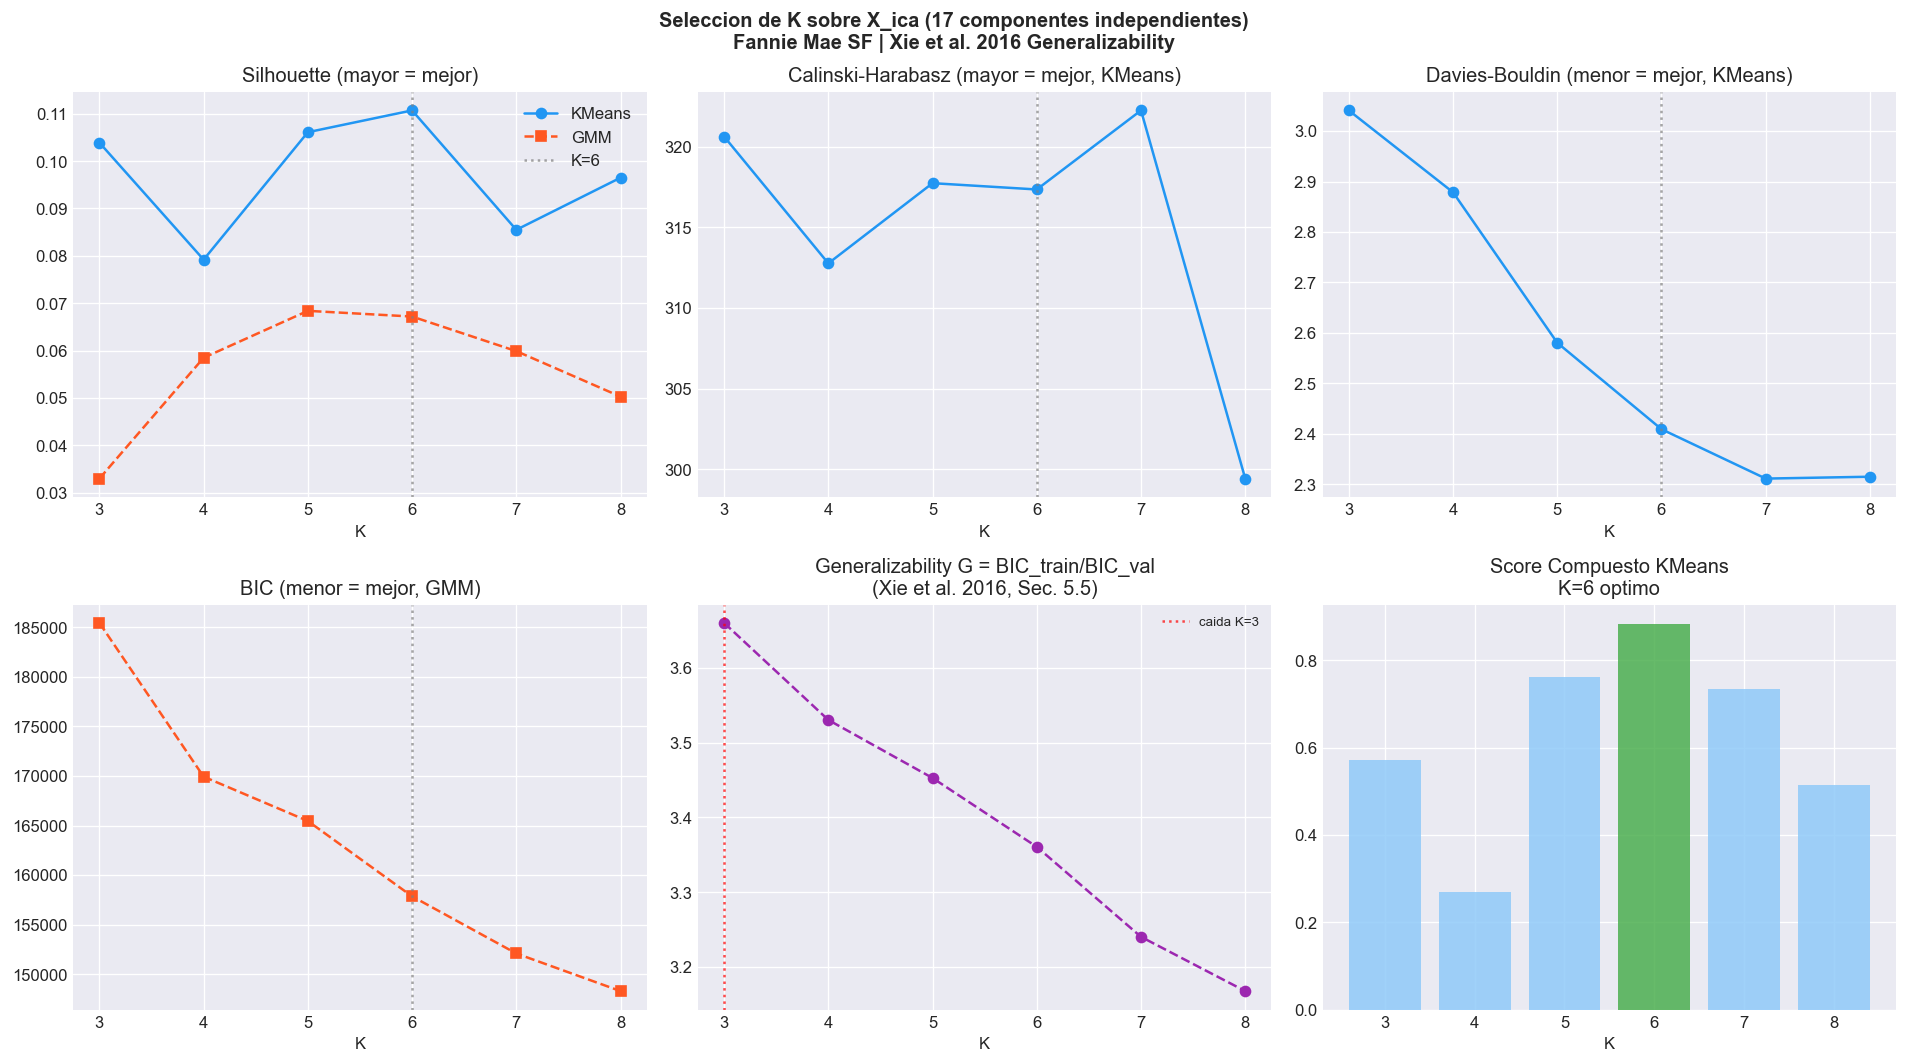

In [33]:
kx = list(K_RANGE)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f'Seleccion de K sobre X_ica ({N_ICA} componentes independientes)\n'
             'Fannie Mae SF | Xie et al. 2016 Generalizability',
             fontsize=12, fontweight='bold')

axes[0,0].plot(kx, km_df.silhouette.values,  'o-', label='KMeans', color='#2196F3')
axes[0,0].plot(kx, gmm_df.silhouette.values, 's--',label='GMM',    color='#FF5722')
axes[0,0].axvline(K_BEST, ls=':', color='gray', alpha=0.7, label=f'K={K_BEST}')
axes[0,0].set_title('Silhouette (mayor = mejor)'); axes[0,0].set_xlabel('K'); axes[0,0].legend()

axes[0,1].plot(kx, km_df.calinski_harabasz.values, 'o-', color='#2196F3')
axes[0,1].axvline(K_BEST, ls=':', color='gray', alpha=0.7)
axes[0,1].set_title('Calinski-Harabasz (mayor = mejor, KMeans)'); axes[0,1].set_xlabel('K')

axes[0,2].plot(kx, km_df.davies_bouldin.values, 'o-', color='#2196F3')
axes[0,2].axvline(K_BEST, ls=':', color='gray', alpha=0.7)
axes[0,2].set_title('Davies-Bouldin (menor = mejor, KMeans)'); axes[0,2].set_xlabel('K')

axes[1,0].plot(kx, gmm_df.bic.values, 's--', color='#FF5722')
axes[1,0].axvline(K_BEST, ls=':', color='gray', alpha=0.7)
axes[1,0].set_title('BIC (menor = mejor, GMM)'); axes[1,0].set_xlabel('K')

axes[1,1].plot(kx, gmm_df.generalizability.values, 's--', color='#9C27B0', marker='o')
axes[1,1].axvline(K_G_OPT, ls=':', color='red', alpha=0.7, label=f'caida K={K_G_OPT}')
axes[1,1].set_title('Generalizability G = BIC_train/BIC_val\n(Xie et al. 2016, Sec. 5.5)')
axes[1,1].set_xlabel('K'); axes[1,1].legend(fontsize=8)

colors = ['#4CAF50' if k == K_BEST else '#90CAF9' for k in km_df.index]
axes[1,2].bar(km_df.index, km_df['score_compuesto'].values, color=colors, alpha=0.85)
axes[1,2].set_title(f'Score Compuesto KMeans\nK={K_BEST} optimo')
axes[1,2].set_xlabel('K')

plt.tight_layout()
plt.savefig(OUT_DIR / '01_seleccion_K.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. K-Means sobre X_ica 

In [34]:
K_FINAL = K_BEST   # ajustar si validacion financiera sugiere otro valor

km_final  = KMeans(n_clusters=K_FINAL, init='k-means++', n_init=20,
                   random_state=RANDOM_STATE, max_iter=500)
labels_km = km_final.fit_predict(X_ica)
df['cluster_kmeans'] = labels_km

sil_km2 = silhouette_score(X_ica, labels_km)
ch_km2  = calinski_harabasz_score(X_ica, labels_km)
db_km2  = davies_bouldin_score(X_ica, labels_km)

print(f'K-Means sobre X_ica (K={K_FINAL})')
print(f'  Silhouette        : {sil_km2:.4f}')
print(f'  Calinski-Harabasz : {ch_km2:,.2f}')
print(f'  Davies-Bouldin    : {db_km2:.4f}')
print(f'\nDistribucion:')
print(pd.Series(labels_km).value_counts().sort_index().rename('n_loans').to_string())

K-Means sobre X_ica (K=6)
  Silhouette        : 0.1107
  Calinski-Harabasz : 317.35
  Davies-Bouldin    : 2.4094

Distribucion:
0     241
1    1026
2    2437
3     618
4     377
5     568


## 6. GMM sobre X_ica 

In [35]:
gmm_final   = GaussianMixture(n_components=K_FINAL, covariance_type='full',
                             n_init=10, random_state=RANDOM_STATE, max_iter=300)
gmm_final.fit(X_ica)
labels_gmm  = gmm_final.predict(X_ica)
proba_gmm   = gmm_final.predict_proba(X_ica)
df['cluster_gmm'] = labels_gmm

sil_gmm2    = silhouette_score(X_ica, labels_gmm)
ch_gmm2     = calinski_harabasz_score(X_ica, labels_gmm)
db_gmm2     = davies_bouldin_score(X_ica, labels_gmm)
uncertainty = 1 - proba_gmm.max(axis=1)

print(f'GMM sobre X_ica (K={K_FINAL}, covariance=full)')
print(f'  Silhouette          : {sil_gmm2:.4f}')
print(f'  Calinski-Harabasz   : {ch_gmm2:,.2f}')
print(f'  Davies-Bouldin      : {db_gmm2:.4f}')
print(f'  BIC                 : {gmm_final.bic(X_ica):,.2f}')
print(f'  AIC                 : {gmm_final.aic(X_ica):,.2f}')
print(f'  Incertidumbre media : {uncertainty.mean():.4f}')
print(f'\nDistribucion:')
print(pd.Series(labels_gmm).value_counts().sort_index().rename('n_loans').to_string())

GMM sobre X_ica (K=6, covariance=full)
  Silhouette          : 0.0763
  Calinski-Harabasz   : 263.33
  Davies-Bouldin      : 2.7116
  BIC                 : 156,966.08
  AIC                 : 150,232.63
  Incertidumbre media : 0.0036

Distribucion:
0     489
1    1726
2    1354
3     421
4     304
5     973


## 7. Clustering Jerarquico sobre X_ica 

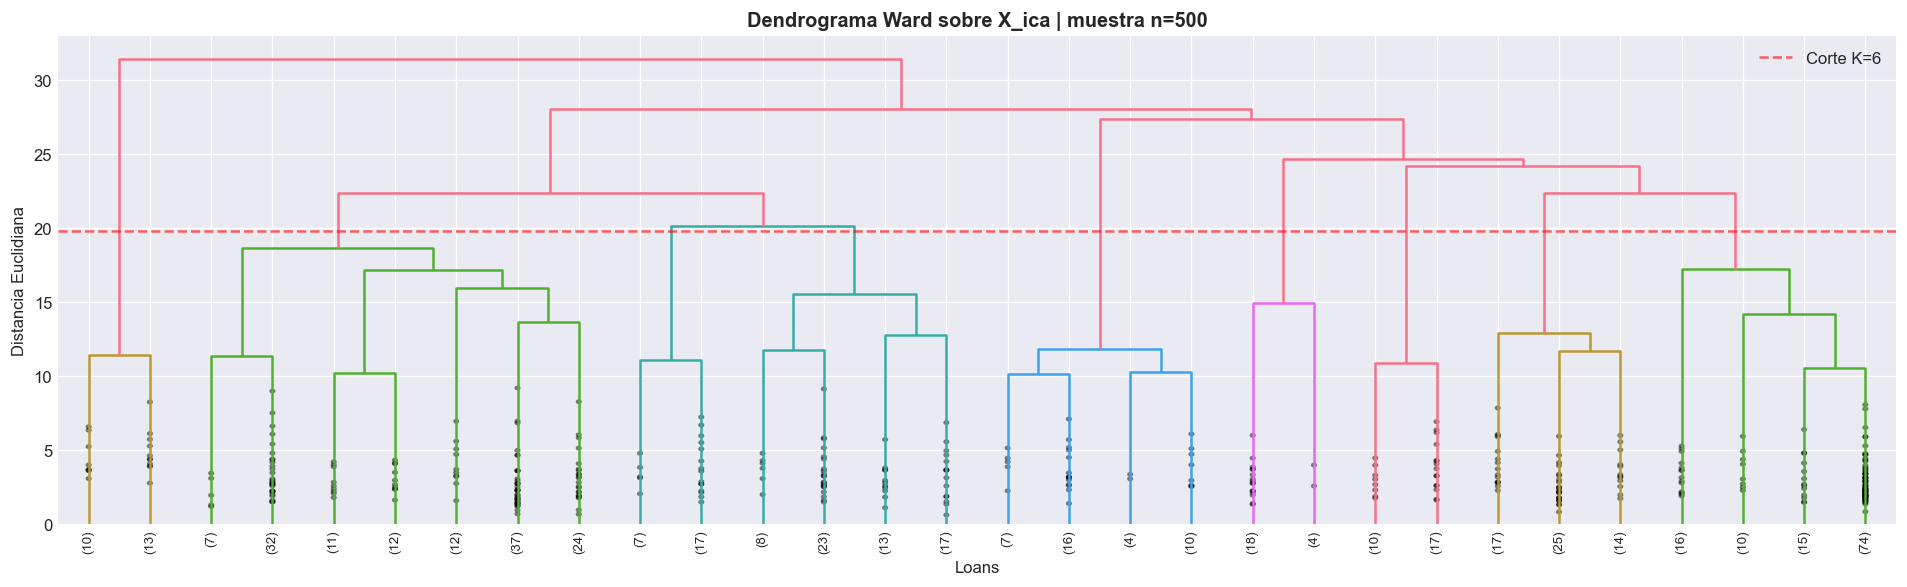

In [36]:
N_DENDRO = 500
idx_d    = np.random.RandomState(RANDOM_STATE).choice(len(X_ica), N_DENDRO, replace=False)
Z_link   = linkage(X_ica[idx_d], method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(16, 5))
dendrogram(Z_link, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8, show_contracted=True)
ax.set_title(f'Dendrograma Ward sobre X_ica | muestra n={N_DENDRO}', fontsize=12, fontweight='bold')
ax.set_xlabel('Loans'); ax.set_ylabel('Distancia Euclidiana')
ax.axhline(y=ax.get_ylim()[1]*0.6, ls='--', color='red', alpha=0.6, label=f'Corte K={K_FINAL}')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / '02_dendrograma.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
hc        = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward')
labels_hc = hc.fit_predict(X_ica)
df['cluster_hc'] = labels_hc

sil_hc2 = silhouette_score(X_ica, labels_hc)
ch_hc2  = calinski_harabasz_score(X_ica, labels_hc)
db_hc2  = davies_bouldin_score(X_ica, labels_hc)

print(f'Jerarquico Ward sobre X_ica (K={K_FINAL})')
print(f'  Silhouette        : {sil_hc2:.4f}')
print(f'  Calinski-Harabasz : {ch_hc2:,.2f}')
print(f'  Davies-Bouldin    : {db_hc2:.4f}')
print(f'\nDistribucion:')
print(pd.Series(labels_hc).value_counts().sort_index().rename('n_loans').to_string())

Jerarquico Ward sobre X_ica (K=6)
  Silhouette        : 0.0819
  Calinski-Harabasz : 283.77
  Davies-Bouldin    : 2.6240

Distribucion:
0    1403
1    2386
2     419
3     240
4     342
5     477


## 8. Deep Embedded Clustering (DEC) — PyTorch

A diferencia de los tres metodos anteriores, DEC no usa `X_ica` — aprende su propia representacion latente `z` optimizando clustering y embedding **al mismo tiempo**.

**Arquitectura:** `38 → 256 → 128 → 64 → 10 (z)`

**Proceso:**
1. Preentrenamiento del autoencoder (MSE, Adam)
2. Inicializacion de centroides con K-Means sobre `z`
3. Optimizacion con KL divergence: minimiza `KL(P || Q)` donde P refuerza asignaciones de alta confianza

In [38]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=10):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, 128),         nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 256),        nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, input_dim)
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

class ClusteringLayer(nn.Module):
    """Eq.(1) Xie et al. 2016 — kernel Student-t, alpha=1"""
    def __init__(self, n_clusters, latent_dim, alpha=1.0):
        super().__init__()
        self.alpha     = alpha
        self.centroids = nn.Parameter(torch.zeros(n_clusters, latent_dim))
    def forward(self, z):
        diff = z.unsqueeze(1) - self.centroids.unsqueeze(0)
        dist = (diff ** 2).sum(dim=2)
        q    = (1.0 + dist / self.alpha) ** (-(self.alpha + 1) / 2.0)
        return q / q.sum(dim=1, keepdim=True)

class DEC(nn.Module):
    def __init__(self, input_dim, n_clusters, latent_dim=10):
        super().__init__()
        self.autoencoder = Autoencoder(input_dim, latent_dim)
        self.clustering  = ClusteringLayer(n_clusters, latent_dim)
    def forward(self, x):
        _, z = self.autoencoder(x)
        return self.clustering(z), z
    @staticmethod
    def target_distribution(q):
        """Eq.(3) Xie et al. 2016 — P = sharpening de Q"""
        f = q.sum(dim=0)
        p = (q ** 2) / f
        return p / p.sum(dim=1, keepdim=True)

LATENT_DIM = 10
BATCH_SIZE = 256
print(f'Arquitectura: {INPUT_DIM}->256->128->64->{LATENT_DIM}')

Arquitectura: 22->256->128->64->10


In [39]:
AE_EPOCHS = 50
dataset    = TensorDataset(X_tensor)
loader     = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
loader_seq = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

ae           = Autoencoder(INPUT_DIM, LATENT_DIM).to(DEVICE)
optimizer_ae = Adam(ae.parameters(), lr=1e-3, weight_decay=1e-5)
ae_losses    = []

print('Preentrenando Autoencoder...')
for epoch in range(AE_EPOCHS):
    ae.train(); ep_loss = 0
    for (xb,) in loader:
        xb = xb.to(DEVICE)
        optimizer_ae.zero_grad()
        recon, _ = ae(xb)
        loss     = nn.MSELoss()(recon, xb)
        loss.backward(); optimizer_ae.step()
        ep_loss += loss.item()
    avg = ep_loss / len(loader)
    ae_losses.append(avg)
    if (epoch + 1) % 10 == 0:
        print(f'  Epoch {epoch+1:3d}/{AE_EPOCHS} | MSE: {avg:.6f}')
print('Autoencoder listo')

Preentrenando Autoencoder...
  Epoch  10/50 | MSE: 0.122275
  Epoch  20/50 | MSE: 0.095430
  Epoch  30/50 | MSE: 0.078410
  Epoch  40/50 | MSE: 0.069154
  Epoch  50/50 | MSE: 0.064287
Autoencoder listo


In [40]:
# Init centroides con K-Means 20 restarts (paper Sec. 3.2)
ae.eval()
z_parts = []
with torch.no_grad():
    for (xb,) in loader_seq:
        _, z = ae(xb.to(DEVICE))
        z_parts.append(z.cpu().numpy())
Z_init = np.concatenate(z_parts)

km_init = KMeans(n_clusters=K_FINAL, init='k-means++', n_init=20, random_state=RANDOM_STATE)
km_init.fit(Z_init)

dec = DEC(INPUT_DIM, K_FINAL, LATENT_DIM).to(DEVICE)
dec.autoencoder.load_state_dict(ae.state_dict())
dec.clustering.centroids.data = torch.tensor(
    km_init.cluster_centers_, dtype=torch.float32).to(DEVICE)

print(f'Centroides DEC inicializados (K-Means 20 restarts sobre z)')
print(f'  Inercia: {km_init.inertia_:.4f}')
print(f'  Shape centroides: {dec.clustering.centroids.shape}')

Centroides DEC inicializados (K-Means 20 restarts sobre z)
  Inercia: 18288.6582
  Shape centroides: torch.Size([6, 10])


In [41]:
# ============================================================
# Paso 3: Entrenamiento DEC
# Nuestro: Adam lr=1e-4
# Del paper: tol=0.1% convergencia (Sec. 3.1.3), target P Eq.(3)
# ============================================================
MAX_EPOCHS  = 150
UPDATE_FREQ = 5      # recalcular P cada N epocas
TOL         = 0.001  # paper Sec. 3.1.3: 'tol = 0.1%'

optimizer_dec = Adam(dec.parameters(), lr=1e-4, weight_decay=1e-5)
kl_crit       = nn.KLDivLoss(reduction='batchmean')
dec_losses    = []
delta_hist    = []

# Asignacion inicial
dec.eval()
q_parts = []
with torch.no_grad():
    for (xb,) in loader_seq:
        q_b, _ = dec(xb.to(DEVICE))
        q_parts.append(q_b.cpu())
prev_labels = torch.cat(q_parts).argmax(dim=1).numpy()

print('Entrenando DEC...')
print(f'  Optimizador      : Adam lr=1e-4  ')
print(f'  Loss             : KL(P||Q), P = Eq.(3) ')
print(f'  Convergencia     : delta < {TOL*100:.1f}% ')

for epoch in range(MAX_EPOCHS):
    # Recalcular P usando la distribucion objetivo del paper (Eq. 3)
    if epoch % UPDATE_FREQ == 0:
        dec.eval()
        q_parts = []
        with torch.no_grad():
            for (xb,) in loader_seq:
                q_b, _ = dec(xb.to(DEVICE))
                q_parts.append(q_b.cpu())
        Q    = torch.cat(q_parts)
        P    = dec.target_distribution(Q).detach()   # Eq. (3) paper

        # Criterio de convergencia del paper (Sec. 3.1.3)
        curr_labels = Q.argmax(dim=1).numpy()
        delta       = float((curr_labels != prev_labels).mean())
        delta_hist.append(delta)
        prev_labels = curr_labels.copy()

        if epoch > 0 and delta < TOL:
            print(f'  Convergencia en epoch {epoch}: delta={delta:.5f} < tol={TOL}')
            break

    dec.train(); ep_loss = 0
    p_loader = DataLoader(TensorDataset(X_tensor, P), batch_size=BATCH_SIZE, shuffle=True)
    for xb, pb in p_loader:
        xb = xb.to(DEVICE); pb = pb.to(DEVICE)
        optimizer_dec.zero_grad()
        q_b, _ = dec(xb)
        loss    = kl_crit(q_b.log(), pb)
        loss.backward(); optimizer_dec.step()
        ep_loss += loss.item()
    avg = ep_loss / len(p_loader)
    dec_losses.append(avg)
    if (epoch + 1) % 25 == 0:
        print(f'  Epoch {epoch+1:4d}/{MAX_EPOCHS} | KL {avg:.6f} | delta {delta:.5f}')

print('Entrenamiento DEC completado')

Entrenando DEC...
  Optimizador      : Adam lr=1e-4  
  Loss             : KL(P||Q), P = Eq.(3) 
  Convergencia     : delta < 0.1% 
  Epoch   25/150 | KL 0.203891 | delta 0.02107
  Epoch   50/150 | KL 0.218946 | delta 0.00740
  Epoch   75/150 | KL 0.215295 | delta 0.00551
  Epoch  100/150 | KL 0.212165 | delta 0.00228
  Convergencia en epoch 120: delta=0.00076 < tol=0.001
Entrenamiento DEC completado


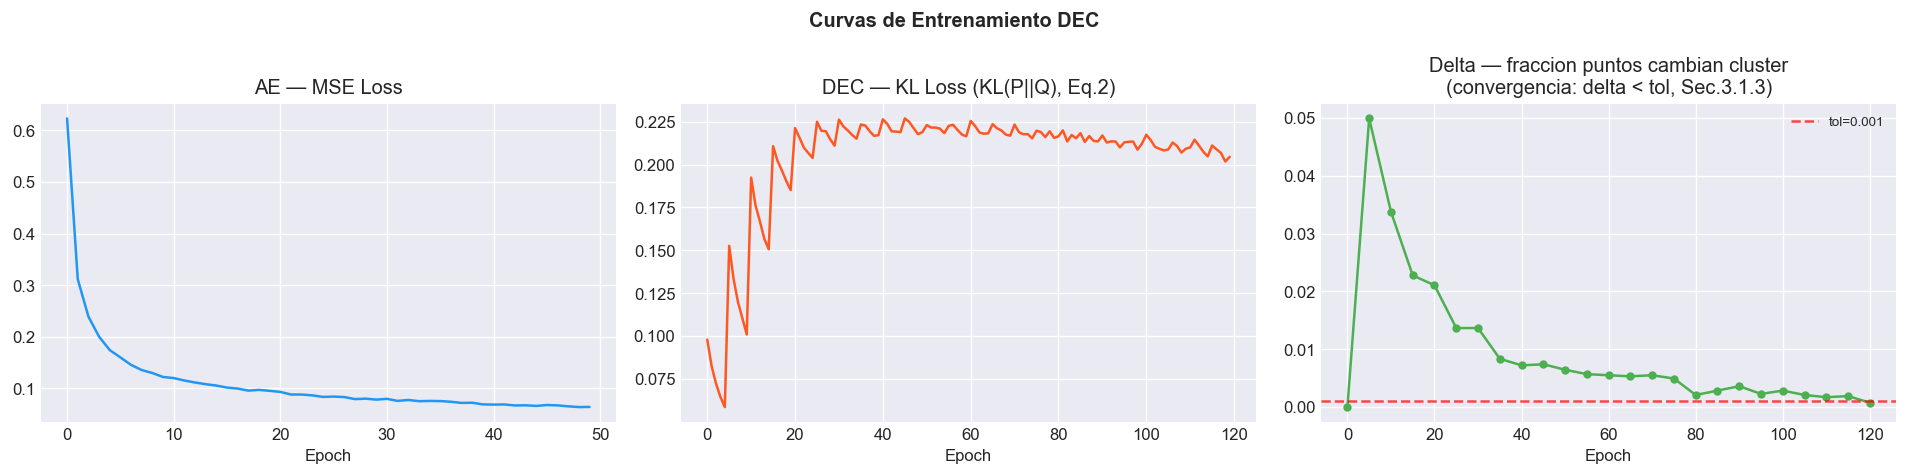

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Curvas de Entrenamiento DEC', fontsize=12, fontweight='bold')
axes[0].plot(ae_losses, color='#2196F3')
axes[0].set_title('AE — MSE Loss'); axes[0].set_xlabel('Epoch')
axes[1].plot(dec_losses, color='#FF5722')
axes[1].set_title('DEC — KL Loss (KL(P||Q), Eq.2)'); axes[1].set_xlabel('Epoch')
delta_epochs = list(range(0, len(delta_hist)*UPDATE_FREQ, UPDATE_FREQ))
axes[2].plot(delta_epochs, delta_hist, color='#4CAF50', marker='o', ms=4)
axes[2].axhline(TOL, ls='--', color='red', alpha=0.7, label=f'tol={TOL}')
axes[2].set_title('Delta — fraccion puntos cambian cluster\n(convergencia: delta < tol, Sec.3.1.3)')
axes[2].set_xlabel('Epoch'); axes[2].legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / '03_dec_training.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
dec.eval()
q_final, z_final = [], []
with torch.no_grad():
    for (xb,) in loader_seq:
        q_b, z_b = dec(xb.to(DEVICE))
        q_final.append(q_b.cpu().numpy())
        z_final.append(z_b.cpu().numpy())

Q_final    = np.concatenate(q_final)
Z_final    = np.concatenate(z_final)
labels_dec = Q_final.argmax(axis=1)
df['cluster_dec'] = labels_dec

sil_dec2 = silhouette_score(Z_final, labels_dec)
ch_dec2  = calinski_harabasz_score(Z_final, labels_dec)
db_dec2  = davies_bouldin_score(Z_final, labels_dec)

print(f'DEC (K={K_FINAL}, espacio latente z de {LATENT_DIM}d)')
print(f'  Silhouette        : {sil_dec2:.4f}')
print(f'  Calinski-Harabasz : {ch_dec2:,.2f}')
print(f'  Davies-Bouldin    : {db_dec2:.4f}')
print(f'\nDistribucion:')
print(pd.Series(labels_dec).value_counts().sort_index().rename('n_loans').to_string())

DEC (K=6, espacio latente z de 10d)
  Silhouette        : 0.9042
  Calinski-Harabasz : 52,795.44
  Davies-Bouldin    : 0.1261

Distribucion:
0    1044
1     500
2     252
3     834
4     935
5    1702


## 9. Comparacion de los 4 metodos

In [44]:
comparison = pd.DataFrame([
    {'Metodo': 'K-Means (ICA)',     'Silhouette': round(sil_km2, 4),  'CH': round(ch_km2, 2),  'DB': round(db_km2, 4),  'Espacio': f'X_ica ({N_ICA}d)', 'Estado': 'Obligatorio'},
    {'Metodo': 'GMM (ICA)',         'Silhouette': round(sil_gmm2, 4), 'CH': round(ch_gmm2, 2), 'DB': round(db_gmm2, 4), 'Espacio': f'X_ica ({N_ICA}d)', 'Estado': 'Obligatorio'},
    {'Metodo': 'Jerarquico (ICA)',  'Silhouette': round(sil_hc2, 4),  'CH': round(ch_hc2, 2),  'DB': round(db_hc2, 4),  'Espacio': f'X_ica ({N_ICA}d)', 'Estado': 'Recomendado'},
    {'Metodo': 'DEC (PyTorch)',     'Silhouette': round(sil_dec2, 4), 'CH': round(ch_dec2, 2), 'DB': round(db_dec2, 4), 'Espacio': f'Latente z ({LATENT_DIM}d)', 'Estado': 'Avanzado'},
]).set_index('Metodo')

print(f'COMPARACION (K={K_FINAL}) — Silhouette mayor=mejor | CH mayor=mejor | DB menor=mejor')
display(comparison.style
        .background_gradient(subset=['Silhouette'], cmap='Greens')
        .background_gradient(subset=['CH'],         cmap='Blues')
        .background_gradient(subset=['DB'],         cmap='Reds_r')
        .format({'Silhouette': '{:.4f}', 'CH': '{:,.2f}', 'DB': '{:.4f}'})
       )

COMPARACION (K=6) — Silhouette mayor=mejor | CH mayor=mejor | DB menor=mejor


,Silhouette,CH,DB,Espacio,Estado
Metodo,,,,,
K-Means (ICA),0.1107,317.35,2.4094,X_ica (17d),Obligatorio
GMM (ICA),0.0763,263.33,2.7116,X_ica (17d),Obligatorio
Jerarquico (ICA),0.0819,283.77,2.6240,X_ica (17d),Recomendado
DEC (PyTorch),0.9042,"52,795.44",0.1261,Latente z (10d),Avanzado


## 10. Visualizacion tSNE

- K-Means, GMM, Jerarquico: proyectados desde `X_ica`
- DEC: proyectado desde el espacio latente `z` aprendido

tSNE sobre X_ica...
tSNE sobre espacio latente DEC z...
listo


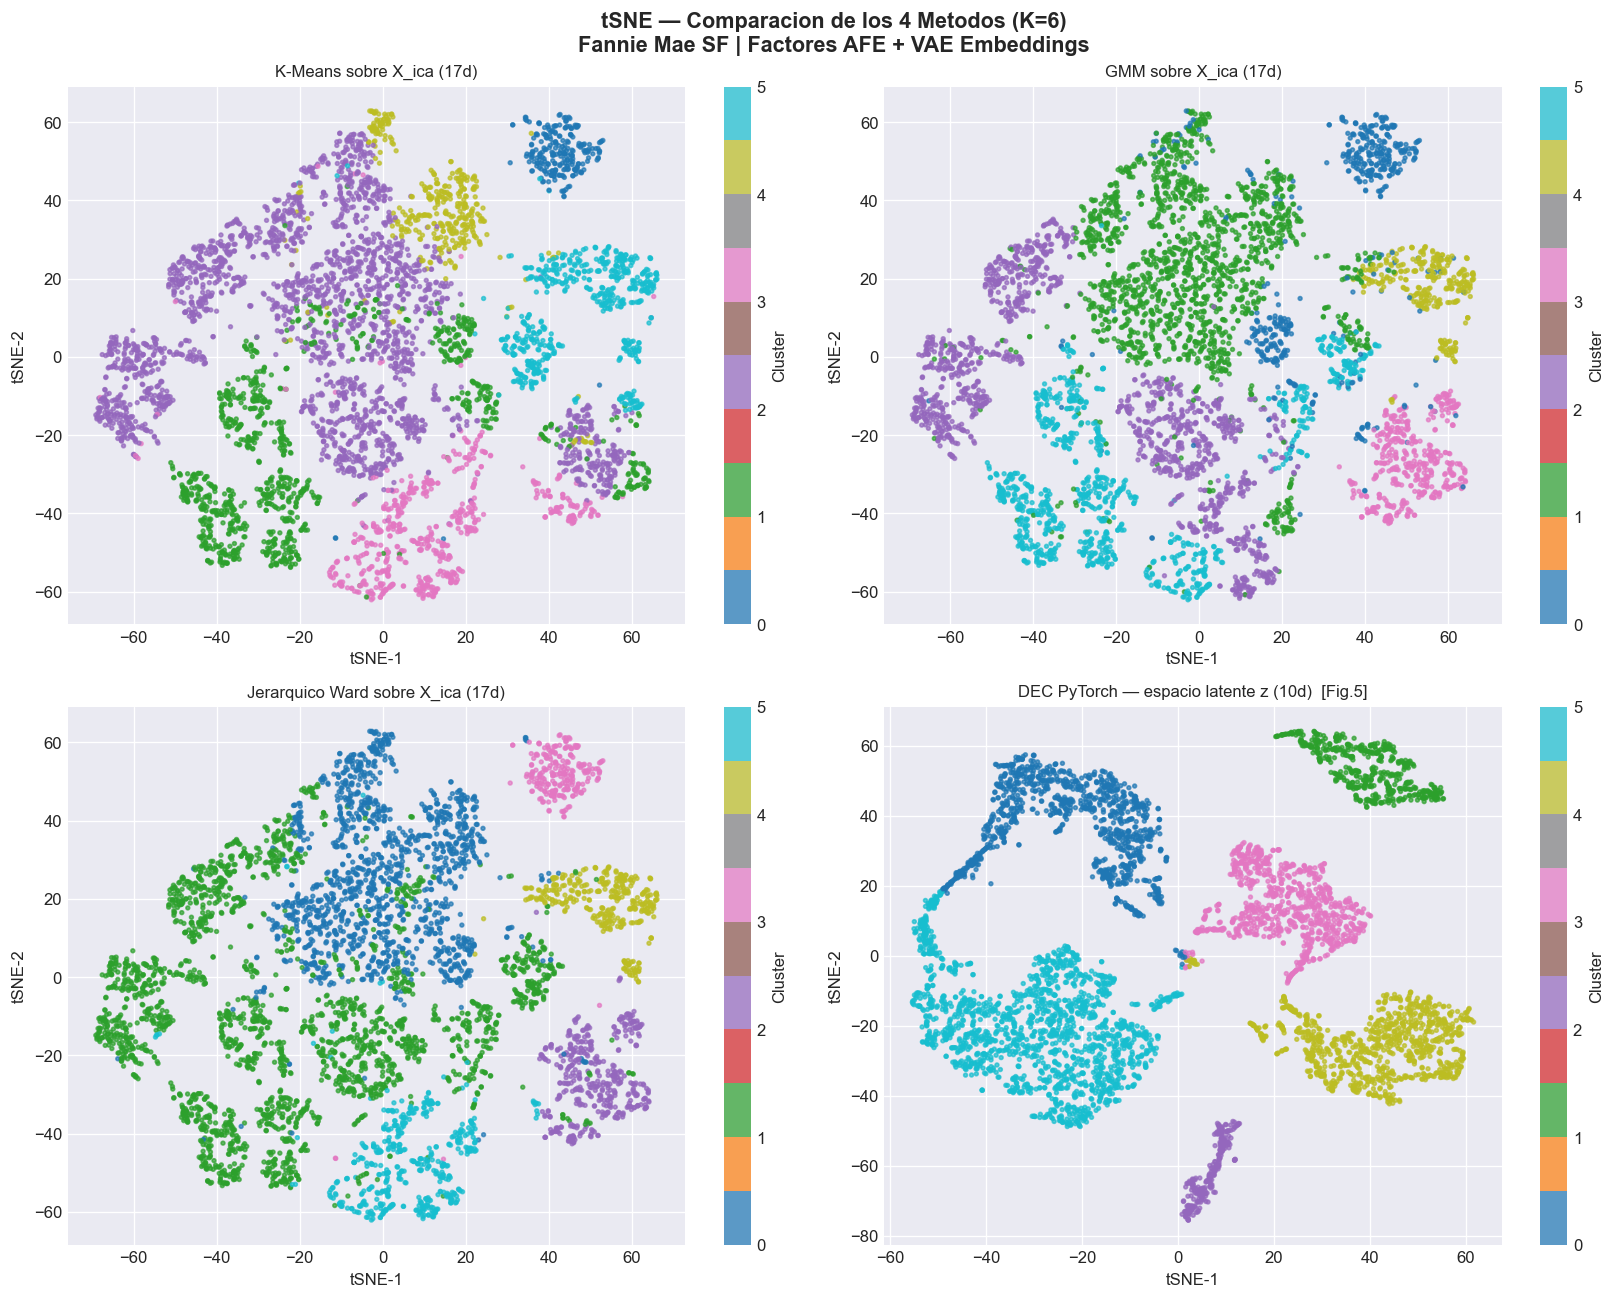

In [45]:
tsne = TSNE(n_components=2, perplexity=40, learning_rate='auto',
            init='pca', random_state=RANDOM_STATE, n_jobs=-1)

print('tSNE sobre X_ica...')
X_tsne_ica = tsne.fit_transform(X_ica)
print('tSNE sobre espacio latente DEC z...')
X_tsne_z   = tsne.fit_transform(Z_final)
print('listo')

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle(f'tSNE — Comparacion de los 4 Metodos (K={K_FINAL})\n'
             'Fannie Mae SF | Factores AFE + VAE Embeddings',
             fontsize=13, fontweight='bold')

for ax, labels, title, coords in [
    (axes[0,0], labels_km,  f'K-Means sobre X_ica ({N_ICA}d)',     X_tsne_ica),
    (axes[0,1], labels_gmm, f'GMM sobre X_ica ({N_ICA}d)',         X_tsne_ica),
    (axes[1,0], labels_hc,  f'Jerarquico Ward sobre X_ica ({N_ICA}d)', X_tsne_ica),
    (axes[1,1], labels_dec, f'DEC PyTorch — espacio latente z ({LATENT_DIM}d)  [Fig.5]', X_tsne_z),
]:
    sc = ax.scatter(coords[:,0], coords[:,1], c=labels, cmap='tab10', s=5, alpha=0.7)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('tSNE-1'); ax.set_ylabel('tSNE-2')
    plt.colorbar(sc, ax=ax, label='Cluster')

plt.tight_layout()
plt.savefig(OUT_DIR / '04_tsne_4metodos.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Exportar resultados del clustering

In [46]:
OUT_DIR = Path('C:/Users/isape/OneDrive/Escritorio/ANALITICA/Proyecto1/punto3/4_CLUSTER')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Etiquetas de los 4 metodos
df[['loan_id','cluster_kmeans','cluster_gmm','cluster_hc','cluster_dec']].to_csv(
    OUT_DIR / 'cluster_labels.csv', index=False)

# Metricas de seleccion de K
metrics_df.to_csv(OUT_DIR / 'selection_metrics.csv', index=False)

# Tabla comparacion de metodos
comparison.to_csv(OUT_DIR / 'comparison_methods.csv')

# Scores ICA
df_ica = pd.DataFrame(X_ica, columns=[f'ic_{i+1}' for i in range(N_ICA)])
df_ica.insert(0, 'loan_id', df['loan_id'].values)
df_ica.to_csv(OUT_DIR / 'ica_scores.csv', index=False)

# Espacio latente DEC (z) — input para la Parte II
df_z = pd.DataFrame(Z_final, columns=[f'dec_z{i}' for i in range(LATENT_DIM)])
df_z.insert(0, 'loan_id', df['loan_id'].values)
df_z.to_csv(OUT_DIR / 'dec_latent_space.csv', index=False)

# Modelo DEC (mejor modelo)
torch.save(dec.state_dict(), OUT_DIR / f'dec_model_K{K_FINAL}.pt')

print('Archivos exportados:')
for f in sorted(OUT_DIR.glob('*')):
    print(f'  {f.name}')

Archivos exportados:
  00_ica_components.png
  01_seleccion_K.png
  02_dendrograma.png
  03_dec_training.png
  04_tsne_4metodos.png
  cluster_labels.csv
  comparison_methods.csv
  dec_latent_space.csv
  dec_model_K6.pt
  fase_iv_clustering_part_FINAL-FINAL.ipynb
  ica_scores.csv
  selection_metrics.csv


## 12. Resumen Ejecutivo

In [47]:
print('=' * 72)
print('  RESUMEN EJECUTIVO — Fase IV Clustering')
print('=' * 72)

print(f'\nDATASET')
print(f'  Loans              : {len(df):,}')
print(f'  Features X_cluster : {INPUT_DIM}  ({len(AFE_FEATURES)} AFE + {len(VAE_FEATURES)} VAE)')

print(f'\nPIPELINE')
print(f'  X_cluster ({INPUT_DIM}d)')
print(f'  └── ICA → X_ica ({N_ICA}d)  ──► K-Means | GMM | Jerarquico')
print(f'  └── X_scaled ({INPUT_DIM}d)   ──► DEC (PyTorch, aprende z de {LATENT_DIM}d)')

print(f'\nSELECCION DE K')
print(f'  Score compuesto (Silhouette + CH + DB) : K = {K_BEST}')
print(f'  Generalizability G (Xie et al. 2016)   : K = {K_G_OPT}')
print(f'  K final utilizado                       : {K_FINAL}')

print(f'\nRESULTADOS (K={K_FINAL})')
print(f'  {"Metodo":<22} {"Silhouette":>11} {"CH":>10} {"DB":>8}  Espacio')
print(f'  {"-"*70}')
print(f'  {"K-Means (ICA)":<22} {sil_km2:>11.4f} {ch_km2:>10,.0f} {db_km2:>8.4f}  X_ica ({N_ICA}d)')
print(f'  {"GMM (ICA)":<22} {sil_gmm2:>11.4f} {ch_gmm2:>10,.0f} {db_gmm2:>8.4f}  X_ica ({N_ICA}d)')
print(f'  {"Jerarquico (ICA)":<22} {sil_hc2:>11.4f} {ch_hc2:>10,.0f} {db_hc2:>8.4f}  X_ica ({N_ICA}d)')
print(f'  {"DEC (PyTorch)":<22} {sil_dec2:>11.4f} {ch_dec2:>10,.0f} {db_dec2:>8.4f}  Latente z ({LATENT_DIM}d)')

best = comparison['Silhouette'].idxmax()
print(f'\n  Mejor metodo por Silhouette  : {best}')
print(f'  K optimo — score compuesto   : {K_BEST}')
print(f'  K optimo — Generalizability  : {K_G_OPT}')

print(f'\nDISTRIBUCION DE CLUSTERS — DEC (mejor modelo)')
print(f'  {"Cluster":<10} {"N loans":>8}  {"% Portfolio":>12}')
print(f'  {"-"*35}')
for cl in sorted(df["cluster_dec"].unique()):
    n   = (df["cluster_dec"] == cl).sum()
    pct = n / len(df) * 100
    print(f'  {cl:<10} {n:>8,}  {pct:>11.1f}%')

print(f'\nARCHIVOS EXPORTADOS → gresults/')
print(f'  cluster_labels.csv      — etiquetas de los 4 metodos por loan')
print(f'  selection_metrics.csv   — metricas K=3..8')
print(f'  comparison_methods.csv  — tabla comparativa final')
print(f'  ica_scores.csv          — {N_ICA} componentes ICA por loan')
print(f'  dec_latent_space.csv    — espacio z ({LATENT_DIM}d) del DEC')
print(f'  dec_model_K{K_FINAL}.pt          — pesos del modelo DEC entrenado')


print('\n' + '=' * 72)

  RESUMEN EJECUTIVO — Fase IV Clustering

DATASET
  Loans              : 5,267
  Features X_cluster : 22  (6 AFE + 16 VAE)

PIPELINE
  X_cluster (22d)
  └── ICA → X_ica (17d)  ──► K-Means | GMM | Jerarquico
  └── X_scaled (22d)   ──► DEC (PyTorch, aprende z de 10d)

SELECCION DE K
  Score compuesto (Silhouette + CH + DB) : K = 6
  Generalizability G (Xie et al. 2016)   : K = 3
  K final utilizado                       : 6

RESULTADOS (K=6)
  Metodo                  Silhouette         CH       DB  Espacio
  ----------------------------------------------------------------------
  K-Means (ICA)               0.1107        317   2.4094  X_ica (17d)
  GMM (ICA)                   0.0763        263   2.7116  X_ica (17d)
  Jerarquico (ICA)            0.0819        284   2.6240  X_ica (17d)
  DEC (PyTorch)               0.9042     52,795   0.1261  Latente z (10d)

  Mejor metodo por Silhouette  : DEC (PyTorch)
  K optimo — score compuesto   : 6
  K optimo — Generalizability  : 3

DISTRIBUCION D